# Fitting

This code generates a plot giving $\Psi$ ($\Psi_X$ in the thesis) for different values of the mass $m$.  

Note that most of this code is copied from the EPTA DR2 GitLab (see Tutorial 02 and 03).  
The GitLab Repository can be found on their website: https://www.epta.eu.org/epta-dr2.html.  

Note that this code shows the general logic, but is not very efficient. A full run can take multiple days.  
Use the Efficiency control parameters in the second Code-Cell to reduce the considered pulsars, MCMC iterations, Fourier modes (red noise) and mass bins. 

### Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import corner
# enterprise 
from enterprise.pulsar import Pulsar 
from enterprise.signals import white_signals, gp_signals, parameter, selections, deterministic_signals, signal_base
from enterprise.signals.utils import powerlaw
from enterprise.signals.signal_base import PTA
from enterprise.signals.selections import Selection
from enterprise_extensions.sampler import JumpProposal 
# PTMCMCSampler
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc

selection = Selection(selections.by_backend)  #used if multiple pulsars are considered

### Efficiency Control

A single run takes quite some time.  
Reduce these parameters to increase speed (by decreasing accuracy).

In [2]:
#MCMC samples, full run: ~5e5
nsamples = int(1e5)
#Number of considered pulsars, full run ~30
npulsars = 10 
#number of mass bins, full run ~1e3
nbins=int(1)
#number of Fourier-modes for rednoise, full run ~30
ncomponents=30 

### Import the Pulsars

Pulsars are imported and packed into the Enterprise object psrs.  
Some of the pulsars do give warnings when loaded since their parfiles do not contain the pulsar distance or a nonstandard format thereof. 

In [3]:
psrnames_all = ["J0030+0451", "J0613-0200", "J1012+5307", "J1022+1001", "J1024-0719", 
                "J1455-3330", "J1600-3053", "J1640+2224", "J1713+0747", "J1730-2304",  
                "J1744-1134", "J1857+0943", "J1909-3744", "J1910+1256", "J1918-0642", 
                "J2124-3358",
                #The following Pulsars give warning when loaded 
                "J0751+1807", "J0900-3144", "J1738+0333", "J1751-2857", "J1801-1417", 
                "J1804-2717", "J1843-1113", "J1911+1347", "J2322+2057"
               ]
psrnames = psrnames_all[:npulsars]
parfiles = [f"../data/DR2new/{p}/{p}.par" for p in psrnames]      #timing model parameters
timfiles = [f"../data/DR2new/{p}/{p}_all.tim" for p in psrnames]  #timefiles

In [4]:
devnull = os.open(os.devnull, os.O_WRONLY)     #these lines are only to avoid 
old_stdout, old_stderr = os.dup(1), os.dup(2)  #debug outputs of Pulsar fct
os.dup2(devnull, 1)                            #
os.dup2(devnull, 2)                            #

psrs = [Pulsar(par, tim, ephem='DE440') for par, tim in zip(parfiles, timfiles)]

os.dup2(old_stdout, 1)     #these lines are only to avoid
os.dup2(old_stderr, 2)     #debug outputs of Pulsar fct
os.close(devnull)          #
os.close(old_stdout)       #
os.close(old_stderr)       #
#print(len(psrs))

### Define Priors

Define the priors according to the Thesis.

In [5]:
log10_m_prior = np.linspace(-24.0, -22.0, nbins)

In [6]:
#white noise
efac_prior = parameter.Uniform(0, 10)
log10_equad_prior = parameter.Uniform(-10, -5)
#rednoise
log10_A_rn_prior = parameter.Uniform(-20, -6)
gamma_rn_prior = parameter.Uniform(0, 10)
#CURN, pulsar independent
log10_A_curn_prior = parameter.Uniform(-20, -6)("curn")
#scalar field parameters, pulsar independent
log10_Psi_X_prior = parameter.Uniform(-20, -12)("log10_Psi")
deltaE_prior      = parameter.Uniform(0, 2)("deltaE")
gammaE_prior      = parameter.Uniform(0, 2*np.pi)("gammaE")
#scalar field parameters, pulsar dependent
deltaP_prior = parameter.Uniform(0, 2)
gammaP_prior = parameter.Uniform(0, 2*np.pi)

### Calculate Expected TOAs

##### Create Timing Model
The Timing Model is included as a Guassian Process. We will marginalized over its parameters.

In [7]:
s = gp_signals.TimingModel()

##### Add white noise

In [8]:
s += white_signals.MeasurementNoise(efac=efac_prior, log10_t2equad=log10_equad_prior, selection=selection)

##### Add red noise

In [9]:
pl = powerlaw(log10_A=log10_A_rn_prior, gamma=gamma_rn_prior)
s += gp_signals.FourierBasisGP(pl, components=ncomponents, selection=selection)

##### Add common uncorrelated red noise (CURN)

In [10]:
pl_curn = powerlaw(log10_A=log10_A_curn_prior, gamma=13/3)  
s += gp_signals.FourierBasisGP(pl_curn, components=ncomponents, name='curn')

##### Add dispersion measure variations (DMV)?

Tutorial 02 includes DMV. The sixth paper of EPTA DR2 which is discussed in the Thesis absorbed DMV in white and red noise. As the goal of this code is to reproduce their results we will do the same. 

##### Add Scalar Field DM induced timing residual

Here we just prepare the function which is added inside the mass-loop


In [11]:
@signal_base.function
def R_m(toas, lgPsi, lgm, dE, dP, gE, gP):
    Psi = 10**lgPsi
    m_eV = 10**lgm
    omega = 2 * m_eV * 1.5192674e15  #2m in rad/s
    t = toas - toas.min()   #sec, shifted
    #measurable timing residual
    Rm = (Psi / omega) * (dE*np.sin(omega*t+gE) + dP*np.sin(omega*t+gP))
    return Rm

### Jump Proposals

If one found a better jump proposal, the code could be more efficient. 

In [12]:
def make_prior_jump(pta, par_match):
    par_list = [p for p in pta.params if par_match in str(p)]
    pmap = {str(p): i for i, p in enumerate(pta.params)}

    def draw(x, iter, beta):
        q = x.copy()
        # choose one matching parameter
        param = np.random.choice(par_list)
        idx = pmap[str(param)]

        old = np.atleast_1d(q[idx]).copy()
        new = np.atleast_1d(param.sample()).copy()

        q[idx] = new[0] if len(new) == 1 else new
        lqxy = np.sum(param.get_logpdf(old)) - np.sum(param.get_logpdf(new))
        return q, float(lqxy)
    return draw


# custom jump proposals
jump_groups = {
    "log10_Psi": 20,
    "gammaE": 10,
    "deltaE": 10,
    "sfdm": 20,
    "red_noise": 10,
    "measurement_noise": 10,
    "curn": 10,
}

## Mass Loop


#### For each mass:    

- Add Scalar Field DM induced Timing Residual
- Create PTA object
- Define Chain location (once)
- Set up the sampler
- Define jumps
- Sample
- Safe Global Parameters

In [13]:
for i, log10_m in enumerate(log10_m_prior):
    #add R_m
    sfdm = deterministic_signals.Deterministic(R_m(lgPsi=log10_Psi_X_prior,
                                                   lgm=log10_m,
                                                   dE=deltaE_prior,
                                                   dP=deltaP_prior,
                                                   gE=gammaE_prior,
                                                   gP=gammaP_prior, ),
                                               name="sfdm"
                                               )
    signal = s + sfdm

    #pta object
    pta = PTA([signal(psr) for psr in psrs])

    #chain location
    outdir = f"./../chains/n_pulsar_{npulsars}/nsamples_{nsamples}/mass_{log10_m:.6f}_ncomponents_{ncomponents}"
    os.makedirs(outdir, exist_ok=True) #create if not there yet
    with open(os.path.join(outdir, "pars.txt"), "w") as fout:  #write pnames
        for pname in pta.param_names:
            fout.write(pname + "\n")

    #sampler setup:
    #there is definitely better ways to define an initial covariance  ---> 
    x0 = np.hstack([p.sample() for p in pta.params]) # Initial sample
    ndim = len(x0)
    cov = np.zeros((ndim, ndim))
    for i, p in enumerate(pta.params):
        draws = np.array([p.sample() for _ in range(200)]).flatten()
        sigma = np.std(draws)
        if not np.isfinite(sigma) or sigma == 0: sigma = 0.1
        cov[i, i] = (0.1 * sigma)**2 #Initial cov-matrix
    print(cov)
    #cov = np.diag(np.ones(ndim) * 0.05**2)
    sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, outDir=outdir) # Sampler

    #jumps
    for name, weight in jump_groups.items():
        if any(name in str(p) for p in pta.params):
            sampler.addProposalToCycle(make_prior_jump(pta, name), weight)

    #sample
    sampler.sample(x0, int(nsamples), SCAMweight=40, DEweight=60, AMweight=5, isave=500)  #too unconstrained for high AM

Finished 0.00 percent in 0.002775 s Acceptance rate = 0

/home/lucal/venvs/epta/lib/python3.12/site-packages/enterprise/signals/parameter.py:70: RuntimeWarning: divide by zero encountered in log
  logpdf = np.log(self.prior(value, **kwargs))


Finished 10.00 percent in 3002.234454 s Acceptance rate = 0.657Adding DE jump with weight 60
Finished 100.00 percent in 32822.003557 s Acceptance rate = 0.47304
Run Complete


### Plotting

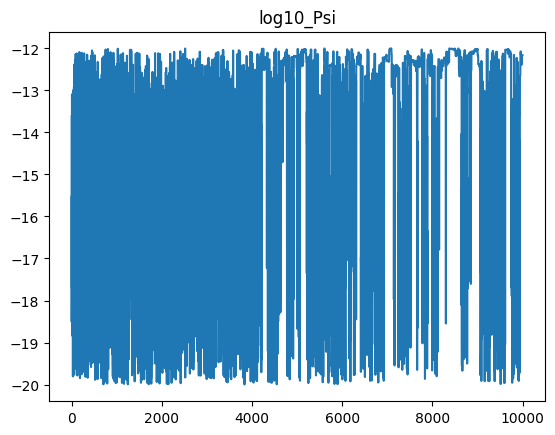

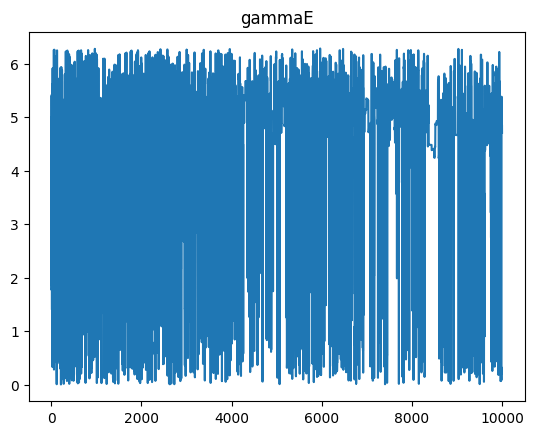

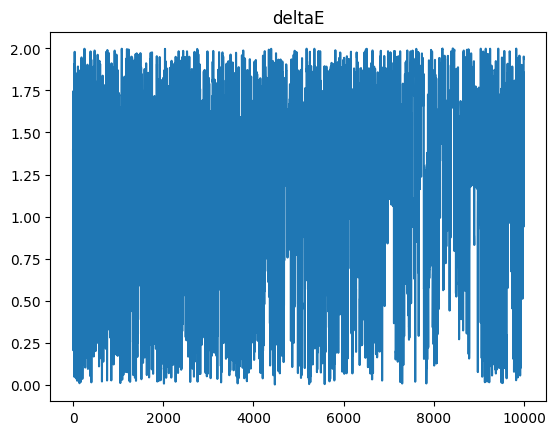

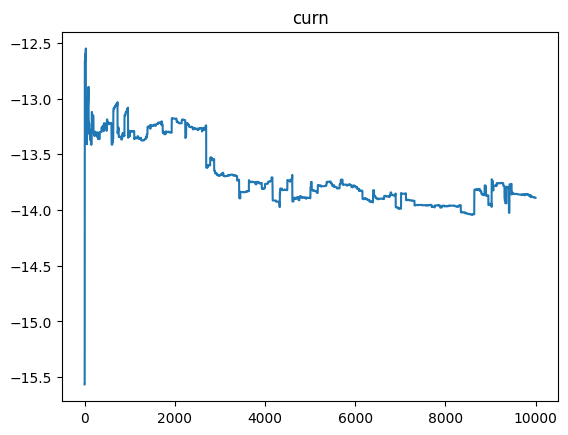

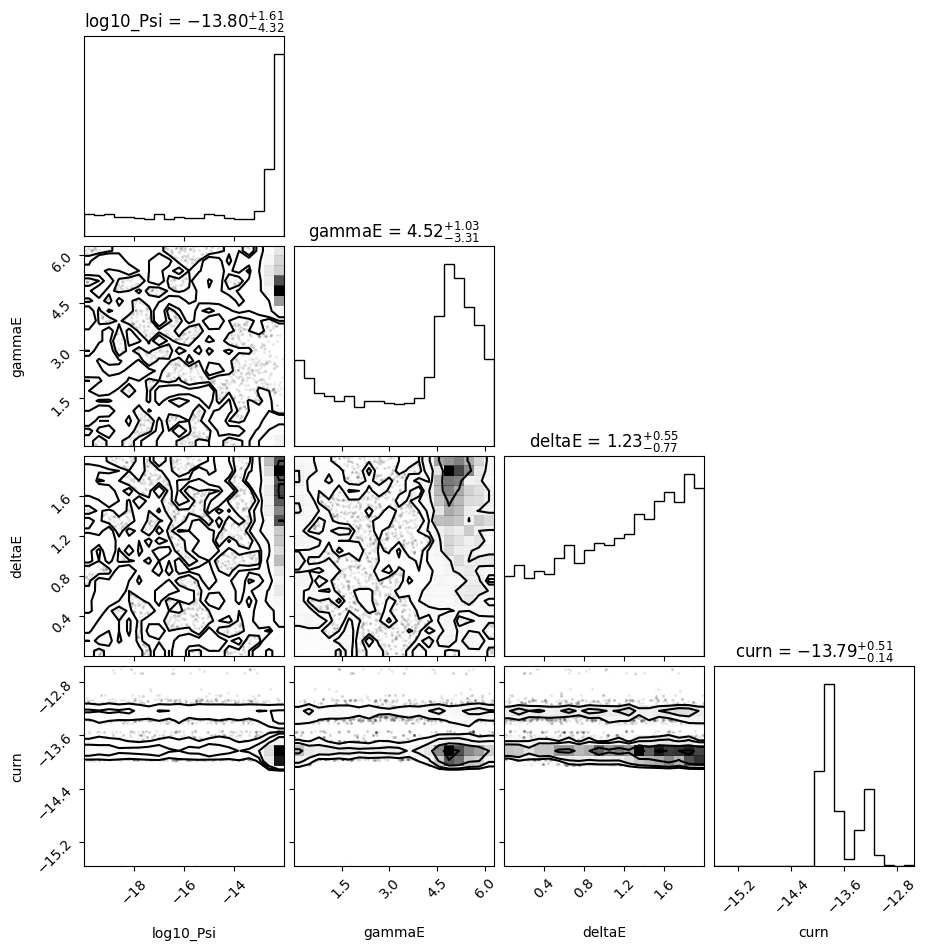

In [19]:
# Load chain file
outdir = f"./../chains/n_pulsar_10/nsamples_100000/mass_-24.000000_ncomponents_30"
ch = np.loadtxt("%s/chain_1.txt"%outdir)

# Remove the burnin
#ch = ch[int(len(ch)*.25):]   
pars = np.loadtxt("%s/pars.txt"%outdir, dtype=str)

# find indices
inds_label = ["log10_Psi", "gammaE", "deltaE", "curn", 
             #'J0030+0451_EFF.P200.1380_efac', 'J1730-2304_red_noise_NRT.NUPPI.2539_gamma', 'J1730-2304_NRT.NUPPI.1484_log10_t2equad',
              #'J1713+0747_red_noise_WSRT.P2.1380_log10_A', 'J1713+0747_sfdm_dP', 'J1713+0747_sfdm_gP'
             ]
inds = []
for ind in inds_label:
    inds.append(list(pars).index(ind))

#chain plot
for i in inds:
    plt.title(pars[i])
    plt.plot(ch[:, i])
    plt.show()

#cornerplot
ch_sub = ch[:, inds]  #only the global param
figure = corner.corner(ch_sub, labels=inds_label, show_titles=True)
plt.show()